     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 12.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.5/163.5 kB 13.8 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=a307741ce009842b6158c3f1745ee6cb38752f6b91837065aef60064f12c4604
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=5c0408d9960a8596cdf9f2318b197e3bd087e5c562cf32c85fe040c7d27ee9bb
  Stored in directory: /root/.cache/pip/wheels/1a/bf/a1/4cee4f7678c68c5875ca89eaccf460593539805c3906722228
Successfully built langdetect docopt
Mounted at /content/drive
Dataset loaded successfully!
Shape: (2838, 11)
Removed 'Unnamed: 10' column.
Handling missing values...
Removed 262 rows with missing reviews
Removed 701 duplicate re

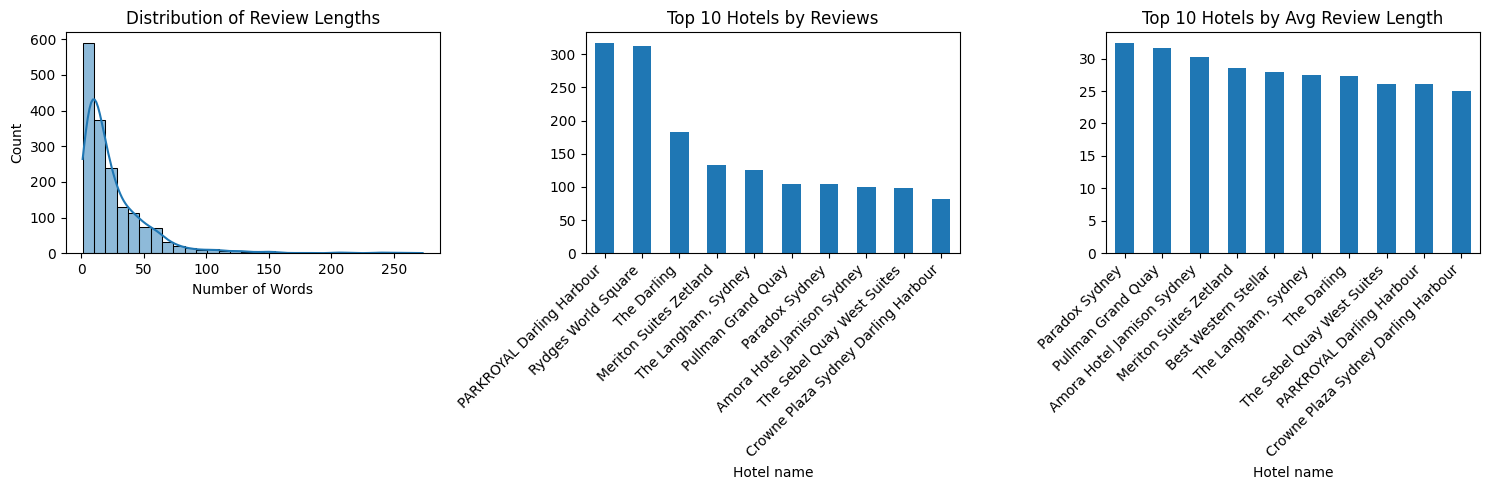


LOADING RoBERTa SENTIMENT ANALYSIS MODEL
Using device: CPU
Loading model: cardiffnlp/twitter-roberta-base-sentiment...


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Device set to use cpu


RoBERTa model loaded successfully!
Analyzing ALL 1717 reviews with RoBERTa...
Processed 8/1717 reviews
Processed 208/1717 reviews
Processed 408/1717 reviews
Processed 608/1717 reviews
Processed 808/1717 reviews
Processed 1008/1717 reviews
Processed 1208/1717 reviews
Processed 1408/1717 reviews
Processed 1608/1717 reviews
RoBERTa sentiment analysis completed!

RoBERTa SENTIMENT ANALYSIS RESULTS - LENIENT APPROACH
LENIENT APPROACH: (Positive + Neutral) = 1, Negative = 0

Detailed Sentiment Distribution:
positive: 1412 reviews (82.2%)
negative: 172 reviews (10.0%)
neutral: 133 reviews (7.7%)

LENIENT BINARY SENTIMENT:
Positive + Neutral (1): 1545 reviews (90.0%)
Negative (0): 172 reviews (10.0%)


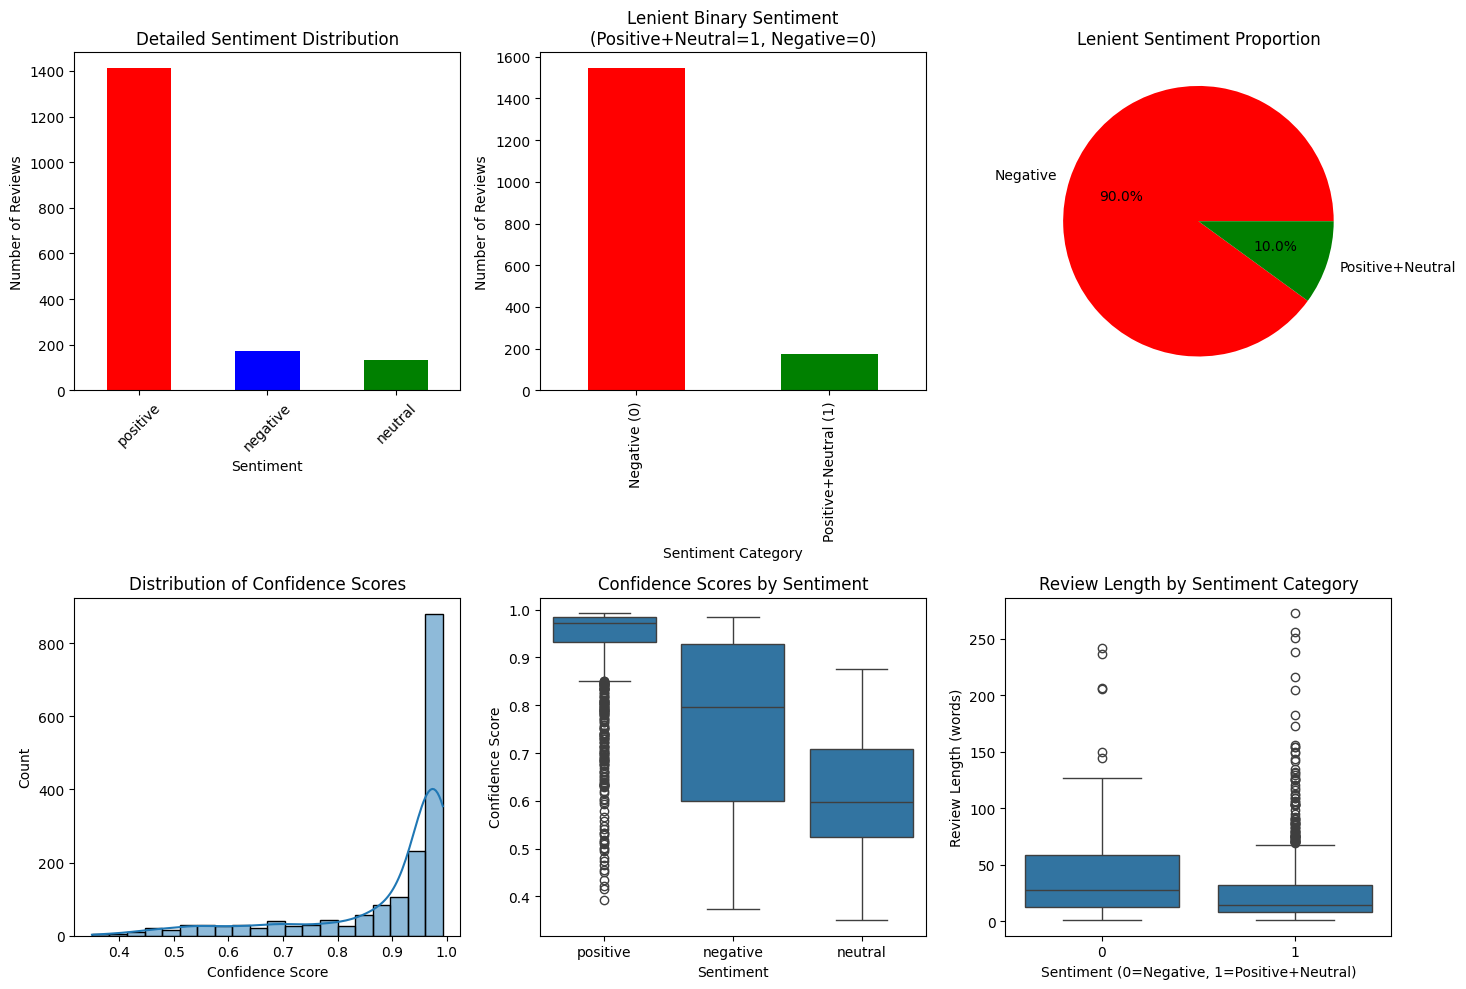


Top 10 Hotels by Number of Reviews:
                                     total_reviews  positive_ratio_lenient  \
Hotel name                                                                   
PARKROYAL Darling Harbour                      317                   0.912   
Rydges World Square                            312                   0.865   
The Darling                                    183                   0.923   
Meriton Suites Zetland                         133                   0.902   
The Langham, Sydney                            126                   0.960   
Paradox Sydney                                 104                   0.904   
Pullman Grand Quay                             104                   0.894   
Amora Hotel Jamison Sydney                     100                   0.870   
The Sebel Quay West Suites                      99                   0.970   
Crowne Plaza Sydney Darling Harbour             82                   0.854   

                          

47645

In [1]:
# -*- coding: utf-8 -*-
"""Hotel Review Sentiment Analysis with RoBERTa (Lenient Approach).ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1_your_drive_link_here
"""

# Install required packages
!pip install transformers torch langdetect num2words
!pip install accelerate -U
!pip install openpyxl
!pip install scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from langdetect import detect, DetectorFactory
import re
from num2words import num2words
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import torch
from scipy.special import softmax
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
DetectorFactory.seed = 0
torch.manual_seed(42)
np.random.seed(42)

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load the data
file_path = '/content/drive/MyDrive/Colab Notebooks/hotel.xlsx'
df = pd.read_excel(file_path)
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

# Remove the 'Unnamed: 10' column if it exists
if 'Unnamed: 10' in df.columns:
    df = df.drop('Unnamed: 10', axis=1)
    print("Removed 'Unnamed: 10' column.")

# Data Cleaning Function
def clean_review_data(df):
    """
    Comprehensive cleaning function for hotel review data
    """
    clean_df = df.copy()

    # 1. Handle missing values
    print("Handling missing values...")
    initial_count = len(clean_df)
    clean_df = clean_df.dropna(subset=['Review Summary'])
    print(f"Removed {initial_count - len(clean_df)} rows with missing reviews")

    # 2. Remove duplicates
    initial_count = len(clean_df)
    clean_df = clean_df.drop_duplicates(subset=['Review Summary'])
    print(f"Removed {initial_count - len(clean_df)} duplicate reviews")

    # 3. Language detection and filtering (English only)
    print("Filtering English reviews...")

    def is_english(text):
        try:
            return detect(str(text)) == 'en'
        except:
            return False

    initial_count = len(clean_df)
    clean_df = clean_df[clean_df['Review Summary'].apply(is_english)]
    print(f"Removed {initial_count - len(clean_df)} non-English reviews")

    # 4. Convert to lowercase
    clean_df['Review Summary'] = clean_df['Review Summary'].str.lower()

    # 5. Handle common abbreviations
    print("Handling abbreviations...")
    abbreviation_map = {
        r'\bbr\b': 'bathroom',
        r'\bw\/': 'with',
        r'\bw\/o\b': 'without',
        r'\brm\b': 'room',
        r'\bbf\b': 'breakfast',
        r'\bac\b': 'air conditioning',
        r'\bwifi\b': 'wi-fi',
        r'\btv\b': 'television',
        r'\bmin\b': 'minute',
        r'\bhr\b': 'hour',
        r'\bstd\b': 'standard',
        r'\bdelux\b': 'deluxe',
        r'\bapt\b': 'apartment',
        r'\bavail\b': 'available',
        r'\bapprox\b': 'approximately',
        r'\bbldg\b': 'building',
        r'\bloc\b': 'location',
        r'\bexcel\b': 'excellent',
        r'\bamt\b': 'amount',
        r'\basap\b': 'as soon as possible',
        r'\beth\b': 'et cetera',
    }

    for abbrev, full_form in abbreviation_map.items():
        clean_df['Review Summary'] = clean_df['Review Summary'].str.replace(abbrev, full_form, regex=True)

    # 6. Convert numbers to words
    print("Converting numbers to words...")

    def convert_numbers(text):
        def num_to_word(match):
            num = match.group()
            try:
                return num2words(int(num))
            except:
                return num

        return re.sub(r'\b\d+\b', num_to_word, text)

    clean_df['Review Summary'] = clean_df['Review Summary'].apply(convert_numbers)

    # 7. Additional cleaning
    clean_df['Review Summary'] = clean_df['Review Summary'].str.replace(r'[^\w\s]', ' ', regex=True)
    clean_df['Review Summary'] = clean_df['Review Summary'].str.replace(r'\s+', ' ', regex=True)
    clean_df['Review Summary'] = clean_df['Review Summary'].str.strip()

    print(f"Final dataset size: {len(clean_df)} reviews")
    return clean_df

# Apply cleaning
cleaned_df = clean_review_data(df)

# EDA Function
def perform_eda(cleaned_df):
    """
    Perform exploratory data analysis on cleaned data
    """
    print("=" * 50)
    print("EXPLORATORY DATA ANALYSIS")
    print("=" * 50)

    print(f"Total hotels: {cleaned_df['Hotel name'].nunique()}")
    print(f"Total reviews: {len(cleaned_df)}")

    # Review length analysis
    cleaned_df['review_length'] = cleaned_df['Review Summary'].apply(lambda x: len(x.split()))

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    sns.histplot(cleaned_df['review_length'], bins=30, kde=True)
    plt.title('Distribution of Review Lengths')
    plt.xlabel('Number of Words')

    plt.subplot(1, 3, 2)
    top_hotels = cleaned_df['Hotel name'].value_counts().head(10)
    top_hotels.plot(kind='bar')
    plt.title('Top 10 Hotels by Reviews')
    plt.xticks(rotation=45, ha='right')

    plt.subplot(1, 3, 3)
    avg_length = cleaned_df.groupby('Hotel name')['review_length'].mean().sort_values(ascending=False).head(10)
    avg_length.plot(kind='bar')
    plt.title('Top 10 Hotels by Avg Review Length')
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()

    return cleaned_df

# Perform EDA
final_df = perform_eda(cleaned_df)

# Load RoBERTa Model for Sentiment Analysis
print("\n" + "=" * 60)
print("LOADING RoBERTa SENTIMENT ANALYSIS MODEL")
print("=" * 60)

# Check if GPU is available
device = 0 if torch.cuda.is_available() else -1
print(f"Using device: {'GPU' if device == 0 else 'CPU'}")

# Load the BEST RoBERTa model for sentiment analysis
model_name = "cardiffnlp/twitter-roberta-base-sentiment"
print(f"Loading model: {model_name}...")

# Initialize the sentiment analysis pipeline
sentiment_analyzer = pipeline(
    "sentiment-analysis",
    model=model_name,
    tokenizer=model_name,
    device=device,
    truncation=True,
    max_length=512,
    batch_size=8
)

print("RoBERTa model loaded successfully!")

# Function for RoBERTa sentiment analysis
def roberta_sentiment_analysis(texts, batch_size=8):
    """
    Perform sentiment analysis using RoBERTa model with batching
    """
    results = []

    # Process in batches to avoid memory issues
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]
        try:
            batch_results = sentiment_analyzer(batch_texts)
            results.extend(batch_results)
            if i % 100 == 0:  # Progress tracking
                print(f"Processed {min(i + batch_size, len(texts))}/{len(texts)} reviews")
        except Exception as e:
            print(f"Error processing batch {i//batch_size + 1}: {e}")
            # Add neutral sentiment for failed analyses
            results.extend([{'label': 'LABEL_1', 'score': 0.5}] * len(batch_texts))

    return results

# Use ALL reviews
analysis_df = final_df.copy()
print(f"Analyzing ALL {len(analysis_df)} reviews with RoBERTa...")

# Perform sentiment analysis
reviews_list = analysis_df['Review Summary'].astype(str).tolist()
sentiment_results = roberta_sentiment_analysis(reviews_list)

# Process RoBERTa results with LENIENT approach
def process_roberta_sentiment(result):
    """
    Process RoBERTa output and convert to numerical scores
    Using LENIENT approach: (Positive + Neutral) = 1, Negative = 0
    """
    label = result['label']
    score = result['score']

    # RoBERTa returns: LABEL_0 (negative), LABEL_1 (neutral), LABEL_2 (positive)
    if label == 'LABEL_0':  # Negative
        return 'negative', score, 0, 0
    elif label == 'LABEL_1':  # Neutral → Considered POSITIVE in lenient approach
        return 'neutral', score, 1, 1
    else:  # LABEL_2 → Positive
        return 'positive', score, 2, 1

# Apply sentiment processing
sentiment_data = [process_roberta_sentiment(result) for result in sentiment_results]
analysis_df['sentiment_label'] = [data[0] for data in sentiment_data]
analysis_df['sentiment_score'] = [data[1] for data in sentiment_data]
analysis_df['sentiment_class'] = [data[2] for data in sentiment_data]
analysis_df['sentiment_binary'] = [data[3] for data in sentiment_data]  # LENIENT: (Positive+Neutral)=1, Negative=0

print("RoBERTa sentiment analysis completed!")

# Results Analysis
print("\n" + "=" * 60)
print("RoBERTa SENTIMENT ANALYSIS RESULTS - LENIENT APPROACH")
print("=" * 60)
print("LENIENT APPROACH: (Positive + Neutral) = 1, Negative = 0")

# Sentiment distribution
sentiment_distribution = analysis_df['sentiment_label'].value_counts()
print("\nDetailed Sentiment Distribution:")
for sentiment, count in sentiment_distribution.items():
    percentage = (count / len(analysis_df)) * 100
    print(f"{sentiment}: {count} reviews ({percentage:.1f}%)")

# Binary sentiment distribution (LENIENT APPROACH)
binary_counts = analysis_df['sentiment_binary'].value_counts()

print(f"\nLENIENT BINARY SENTIMENT:")
positive_count = binary_counts.get(1, 0)
negative_count = binary_counts.get(0, 0)
positive_percentage = (positive_count / len(analysis_df)) * 100
negative_percentage = (negative_count / len(analysis_df)) * 100

print(f"Positive + Neutral (1): {positive_count} reviews ({positive_percentage:.1f}%)")
print(f"Negative (0): {negative_count} reviews ({negative_percentage:.1f}%)")

# Visualizations
plt.figure(figsize=(15, 10))

# Detailed sentiment distribution
plt.subplot(2, 3, 1)
sentiment_distribution.plot(kind='bar', color=['red', 'blue', 'green'])
plt.title('Detailed Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)

# Lenient binary sentiment
plt.subplot(2, 3, 2)
binary_counts.plot(kind='bar', color=['red', 'green'])
plt.title('Lenient Binary Sentiment\n(Positive+Neutral=1, Negative=0)')
plt.xlabel('Sentiment Category')
plt.ylabel('Number of Reviews')
plt.xticks([0, 1], ['Negative (0)', 'Positive+Neutral (1)'])

# Pie chart for lenient approach
plt.subplot(2, 3, 3)
binary_counts.plot(kind='pie', autopct='%1.1f%%', colors=['red', 'green'],
                   labels=['Negative', 'Positive+Neutral'])
plt.title('Lenient Sentiment Proportion')
plt.ylabel('')

# Confidence scores distribution
plt.subplot(2, 3, 4)
sns.histplot(analysis_df['sentiment_score'], bins=20, kde=True)
plt.title('Distribution of Confidence Scores')
plt.xlabel('Confidence Score')

# Sentiment vs Confidence
plt.subplot(2, 3, 5)
sns.boxplot(x='sentiment_label', y='sentiment_score', data=analysis_df)
plt.title('Confidence Scores by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Confidence Score')

# Review length vs Sentiment
plt.subplot(2, 3, 6)
sns.boxplot(x='sentiment_binary', y='review_length', data=analysis_df)
plt.title('Review Length by Sentiment Category')
plt.xlabel('Sentiment (0=Negative, 1=Positive+Neutral)')
plt.ylabel('Review Length (words)')

plt.tight_layout()
plt.show()

# Hotel-wise analysis with LENIENT approach
hotel_sentiment = analysis_df.groupby('Hotel name').agg({
    'sentiment_binary': ['count', 'mean'],  # Using lenient binary
    'sentiment_score': 'mean'
}).round(3)

hotel_sentiment.columns = ['total_reviews', 'positive_ratio_lenient', 'avg_confidence']
hotel_sentiment = hotel_sentiment.sort_values('total_reviews', ascending=False)

print("\nTop 10 Hotels by Number of Reviews:")
print(hotel_sentiment.head(10))

# Hotels with best sentiment (min 3 reviews) - LENIENT APPROACH
min_reviews = 3
qualified_hotels = hotel_sentiment[hotel_sentiment['total_reviews'] >= min_reviews]

print(f"\nTop 10 Hotels with Best Sentiment (LENIENT, min {min_reviews} reviews):")
top_positive = qualified_hotels.sort_values('positive_ratio_lenient', ascending=False).head(10)
print(top_positive)

print(f"\nTop 10 Hotels with Worst Sentiment (LENIENT, min {min_reviews} reviews):")
top_negative = qualified_hotels.sort_values('positive_ratio_lenient', ascending=True).head(10)
print(top_negative)

# Save results
output_path = '/content/drive/MyDrive/Colab Notebooks/hotel_reviews_roberta_lenient_sentiment.xlsx'
analysis_df.to_excel(output_path, index=False)
print(f"\nResults saved to: {output_path}")

# Example reviews with LENIENT classification
print("\n" + "=" * 70)
print("EXAMPLE REVIEWS - LENIENT APPROACH (Positive+Neutral=1, Negative=0)")
print("=" * 70)

print("\n✅ Example POSITIVE+NEUTRAL Reviews (Classified as 1):")
positive_neutral_examples = analysis_df[analysis_df['sentiment_binary'] == 1].sample(4)
for idx, row in positive_neutral_examples.iterrows():
    print(f"\nSentiment: {row['sentiment_label']} → Binary: {row['sentiment_binary']} (Confidence: {row['sentiment_score']:.3f})")
    print(f"Review: {row['Review Summary'][:120]}...")

print("\n❌ Example NEGATIVE Reviews (Classified as 0):")
negative_examples = analysis_df[analysis_df['sentiment_binary'] == 0].sample(3)
for idx, row in negative_examples.iterrows():
    print(f"\nSentiment: {row['sentiment_label']} → Binary: {row['sentiment_binary']} (Confidence: {row['sentiment_score']:.3f})")
    print(f"Review: {row['Review Summary'][:120]}...")

# Detailed statistics
print("\n" + "=" * 60)
print("DETAILED STATISTICS - LENIENT APPROACH")
print("=" * 60)

print(f"\nTotal reviews analyzed: {len(analysis_df)}")
print(f"Average confidence score: {analysis_df['sentiment_score'].mean():.3f}")

print(f"\nLenient Sentiment Breakdown:")
print(f"Positive+Neutral (1): {positive_count} reviews ({positive_percentage:.1f}%)")
print(f"Negative (0): {negative_count} reviews ({negative_percentage:.1f}%)")

print(f"\nDetailed Breakdown:")
positive_count_detailed = sentiment_distribution.get('positive', 0)
neutral_count_detailed = sentiment_distribution.get('neutral', 0)
negative_count_detailed = sentiment_distribution.get('negative', 0)

positive_percentage_detailed = (positive_count_detailed / len(analysis_df)) * 100
neutral_percentage_detailed = (neutral_count_detailed / len(analysis_df)) * 100
negative_percentage_detailed = (negative_count_detailed / len(analysis_df)) * 100

print(f"Positive: {positive_count_detailed} ({positive_percentage_detailed:.1f}%)")
print(f"Neutral: {neutral_count_detailed} ({neutral_percentage_detailed:.1f}%)")
print(f"Negative: {negative_count_detailed} ({negative_percentage_detailed:.1f}%)")

# Confidence by binary sentiment
confidence_stats = analysis_df.groupby('sentiment_binary')['sentiment_score'].describe()
print("\nConfidence Score Statistics by Binary Sentiment:")
print(confidence_stats)

print("\nRoBERTa analysis with LENIENT approach complete! ✅")

# Memory cleanup
import gc
del sentiment_analyzer
torch.cuda.empty_cache() if torch.cuda.is_available() else None
gc.collect()